# Corrected Metals Flow-Filtered Residual Reversion Review

This notebook reviews HYP-0015 and compares it against the invalidated HYP-0014 run. The key correction is that all-outright trades are used only for flow features, while traded returns and residual z-scores are computed from roll-adjusted 1-minute continuous marks sampled at cross-sectional dollar-bar end times.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display, Markdown

BASE = Path('/home/famadeo/quant-lab')
OLD = BASE / 'experiments/HYP-0014-metals-flow-filtered-residual-reversion-3y'
NEW = BASE / 'experiments/HYP-0015-metals-flow-corrected-residual-reversion'
ROOTS = ['GC', 'SI', 'HG', 'PL', 'PA']
plt.style.use('seaborn-v0_8-whitegrid')


## Load Artifacts

In [2]:
def load_exp(path):
    data = {
        'results': json.loads((path / 'results.json').read_text()),
        'variants': pd.read_csv(path / 'variants.csv'),
        'split': pd.read_csv(path / 'split_metrics.csv'),
        'monthly': pd.read_csv(path / 'monthly_returns.csv'),
        'selected': pd.read_parquet(path / 'selected_returns.parquet'),
        'positions': pd.read_parquet(path / 'positions.parquet'),
        'bars': pd.read_parquet(path / 'bars.parquet'),
        'returns': pd.read_parquet(path / 'returns.parquet'),
        'ic_fdr': pd.read_csv(path / 'ic_fdr.csv'),
    }
    optional = ['trade_inventory.csv', 'price_validity.parquet', 'continuous_marks.parquet', 'endpoint_symbols.parquet', 'leakage_diagnostics.csv', 'daily_hac.csv', 'size_thresholds.csv']
    for name in optional:
        p = path / name
        if p.exists():
            key = p.stem
            data[key] = pd.read_parquet(p) if p.suffix == '.parquet' else pd.read_csv(p)
    return data

old = load_exp(OLD)
new = load_exp(NEW)


## Headline Comparison

In [3]:
def metrics_row(label, exp):
    m = exp['results']['summary']['selected_strategy_metrics']
    return {
        'run': label,
        'gross_return': m['gross_return'],
        'cost_return': m['cost_return'],
        'net_return': m['net_return'],
        'gross_to_cost': m['gross_to_cost'],
        'tstat': m['tstat'],
        'annualized_sharpe': m['annualized_sharpe'],
        'max_drawdown': m['max_drawdown'],
        'active_bars': m['active_bars'],
        'turnover': m['turnover'],
    }

headline = pd.DataFrame([
    metrics_row('HYP-0014 invalid mixed-contract returns', old),
    metrics_row('HYP-0015 corrected continuous marks', new),
])
headline


,run,gross_return,cost_return,net_return,gross_to_cost,tstat,annualized_sharpe,max_drawdown,active_bars,turnover
0,HYP-0014 invalid mixed-contract returns,4.026673,0.356518,3.670155,11.294454,9.019133,5.206611,-0.074999,33646,1527.166667
1,HYP-0015 corrected continuous marks,0.182592,0.391054,-0.208462,0.466923,-0.997715,-0.575966,-0.496925,114817,1688.694444


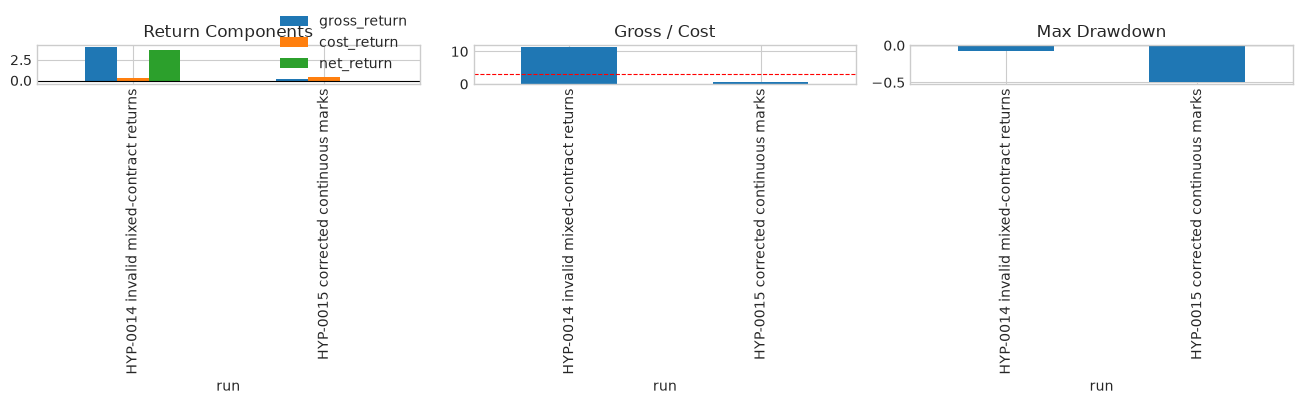

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
headline.set_index('run')[['gross_return','cost_return','net_return']].plot.bar(ax=axes[0])
axes[0].set_title('Return Components')
axes[0].axhline(0, color='black', linewidth=0.8)
headline.set_index('run')[['gross_to_cost']].plot.bar(ax=axes[1], legend=False)
axes[1].set_title('Gross / Cost')
axes[1].axhline(3, color='red', linestyle='--', linewidth=0.8)
headline.set_index('run')[['max_drawdown']].plot.bar(ax=axes[2], legend=False)
axes[2].set_title('Max Drawdown')
axes[2].axhline(0, color='black', linewidth=0.8)
fig.tight_layout()
plt.show()


## Corrected Run Diagnostics

In [5]:
summary = new['results']['summary']
corrected_diag = pd.Series({
    'primary_complete_bars': summary['primary_complete_bars'],
    'valid_price_fraction': summary['valid_price_fraction'],
    'fresh_all_fraction': summary['fresh_all_fraction'],
    'roll_invalid_fraction': summary['roll_invalid_fraction'],
    'post_2025_10_net': summary['post_2025_10_net'],
    'post_2025_10_share_of_total_net': summary['post_2025_10_share_of_total_net'],
    'fdr_significant_tests': summary['fdr_significant_tests'],
})
corrected_diag


primary_complete_bars              242166.000000
valid_price_fraction                    0.998059
fresh_all_fraction                      0.998749
roll_invalid_fraction                   0.000710
post_2025_10_net                        0.205535
post_2025_10_share_of_total_net        -0.985958
fdr_significant_tests                 251.000000
dtype: float64

In [6]:
display(new['trade_inventory'])
display(new['size_thresholds'])


,root,trades,start_ts,end_ts,symbol_count,notional,signed_ratio,side_n_notional_share,median_trade_size,p99_trade_size,median_trade_notional,p99_trade_notional,exact_duplicate_extra_rows
0,GC,82365734,2023-06-22 00:00:04.064891+00:00,2026-06-21 23:59:56.082051+00:00,64,4.338755e+13,-0.001923,0.040390,1.0,9.0,399060.0,2635680.0,394104.0
1,SI,29540740,2023-06-22 00:00:03.966970+00:00,2026-06-21 23:59:52.143142+00:00,56,1.055431e+13,-0.001314,0.038511,1.0,10.0,247950.0,1895800.0,142396.0
2,HG,25318855,2023-06-22 00:00:00.162726+00:00,2026-06-21 23:59:56.506287+00:00,62,5.043377e+12,-0.002765,0.069352,1.0,10.0,126212.5,1060560.5,134913.0
3,PL,13719194,2023-06-22 00:01:10.756358+00:00,2026-06-21 23:58:25.144921+00:00,47,1.279003e+12,-0.003135,0.062179,1.0,7.0,69405.0,415320.0,29539.0
4,PA,2386009,2023-06-22 00:33:24.040162+00:00,2026-06-21 23:55:48.277942+00:00,45,4.127516e+11,-0.007528,0.035602,1.0,6.0,128600.0,694050.0,5255.0


,root_code,calibration_trades,calibration_start,calibration_end,q50_size,q90_size,q99_size,root
0,0,1744463,2023-06-22 00:00:04.064891+00:00,2023-07-21 20:59:56.098268+00:00,1.0,4.0,13.0,GC
1,1,553017,2023-06-22 00:00:03.966970+00:00,2023-07-21 20:59:58.213461+00:00,1.0,4.0,12.0,SI
2,2,706187,2023-06-22 00:00:00.162726+00:00,2023-07-21 20:59:55.113014+00:00,1.0,3.0,11.0,HG
3,3,284708,2023-06-22 00:01:10.756358+00:00,2023-07-21 20:59:58.013231+00:00,1.0,2.0,6.0,PL
4,4,33948,2023-06-22 00:33:24.040162+00:00,2023-07-21 20:58:39.199421+00:00,1.0,2.0,4.0,PA


## Equity, Drawdown, And Costs

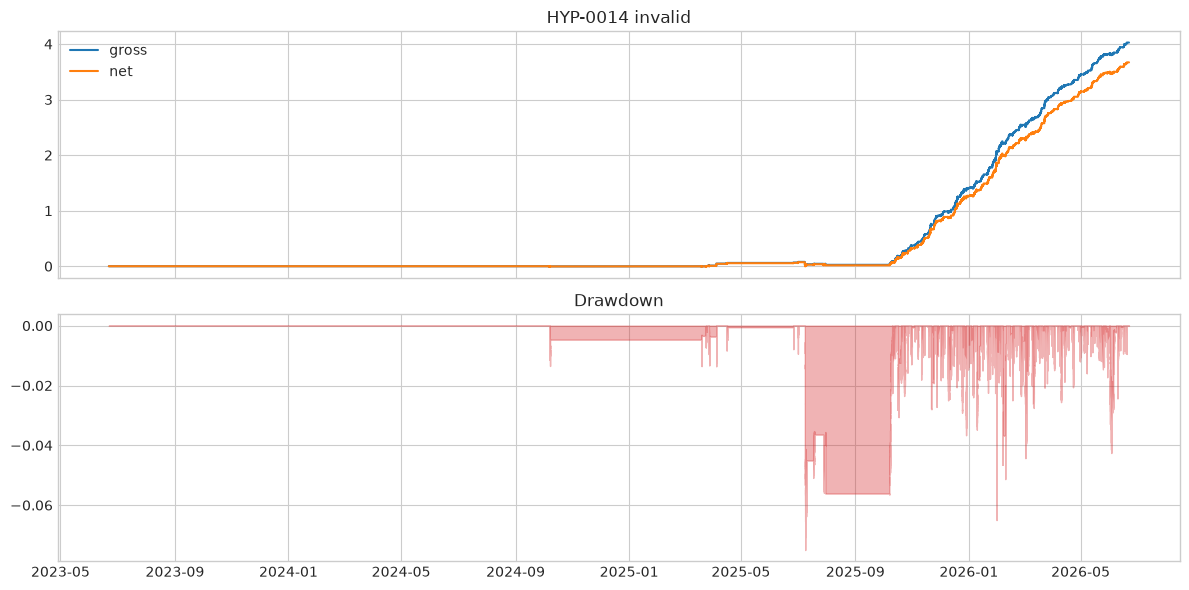

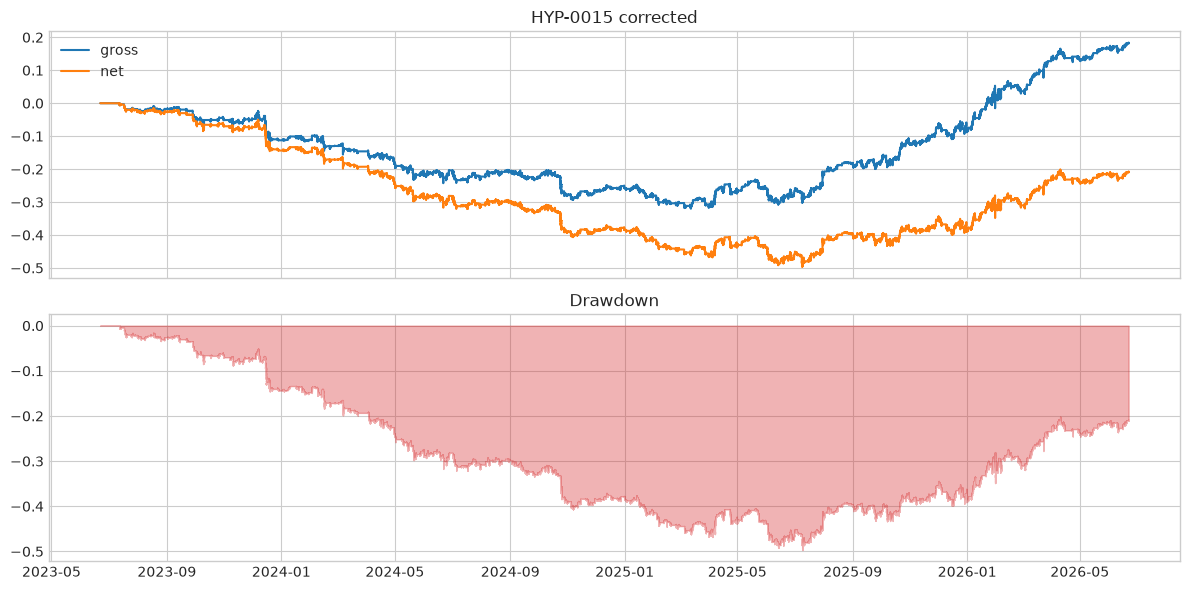

In [7]:
for label, exp in [('HYP-0014 invalid', old), ('HYP-0015 corrected', new)]:
    ts = pd.to_datetime(exp['bars']['end_ts'], utc=True)
    selected = exp['selected']
    equity = selected['net_return'].cumsum()
    dd = equity - equity.cummax()
    fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
    axes[0].plot(ts, selected['gross_return'].cumsum(), label='gross')
    axes[0].plot(ts, equity, label='net')
    axes[0].set_title(label)
    axes[0].legend()
    axes[1].fill_between(ts, dd, 0, color='tab:red', alpha=0.35)
    axes[1].set_title('Drawdown')
    fig.tight_layout()
    plt.show()


,variant,cost_multiplier,observations,active_bars,gross_return,cost_return,net_return,mean_net_bps,tstat,annualized_sharpe,hit_rate,max_drawdown,gross_to_cost,turnover
0,cost_0.0,0.0,242166,114817,0.182592,0.000000,0.182592,0.007540,0.872935,0.503933,0.218036,-0.320549,inf,1688.694444
1,cost_1.0,1.0,242166,114817,0.182592,0.391054,-0.208462,-0.008608,-0.997715,-0.575966,0.217421,-0.496925,0.466923,1688.694444
2,cost_2.0,2.0,242166,114817,0.182592,0.782109,-0.599516,-0.024756,-2.866679,-1.654891,0.216835,-0.694367,0.233462,1688.694444
3,cost_3.0,3.0,242166,114817,0.182592,1.173163,-0.990571,-0.040905,-4.722640,-2.726310,0.216232,-1.014748,0.155641,1688.694444
4,cost_5.0,5.0,242166,114817,0.182592,1.955271,-1.772679,-0.073201,-8.352434,-4.821736,0.215443,-1.788916,0.093385,1688.694444
5,cost_10.0,10.0,242166,114817,0.182592,3.910543,-3.727951,-0.153942,-16.544762,-9.551045,0.214811,-3.735489,0.046692,1688.694444


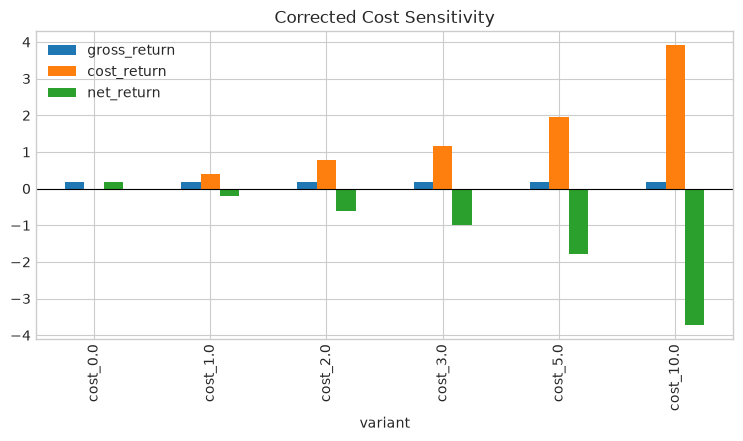

In [8]:
display(new['variants'])
fig, ax = plt.subplots(figsize=(9, 4))
new['variants'].set_index('variant')[['gross_return','cost_return','net_return']].plot.bar(ax=ax)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('Corrected Cost Sensitivity')
plt.show()


## Split And Dependence-Adjusted Evidence

In [9]:
display(new['split'])
display(new['daily_hac'])


,split,start_ts,end_ts,split_index,test_start_index,observations,active_bars,gross_return,cost_return,net_return,mean_net_bps,tstat,annualized_sharpe,hit_rate,max_drawdown,gross_to_cost,turnover
0,train,2023-06-22 00:45:01.900427+00:00,2025-11-14 06:23:22.751343+00:00,169516,169589,169516,84279,-0.112083,0.270561,-0.382644,-0.022573,-2.299751,-1.586801,0.232869,-0.496925,-0.414263,1174.944444
1,test_purged,2025-11-14 10:05:00.314564+00:00,2026-06-21 23:56:08.707536+00:00,169516,169589,72577,30465,0.297816,0.120142,0.177674,0.024481,1.408669,1.485444,0.181118,-0.068490,2.478872,512.750000


,frequency,lags,observations,mean,tstat,net_return
0,daily,0,934,-0.000223,-1.184023,-0.208462
1,daily,5,934,-0.000223,-1.145579,-0.208462
2,daily,20,934,-0.000223,-1.090222,-0.208462
3,daily,60,934,-0.000223,-0.991352,-0.208462
4,daily,120,934,-0.000223,-0.812192,-0.208462


## Monthly Attribution

,month,old_net,new_net
0,2023-06,0.000000,0.000000
1,2023-07,0.000000,-0.026174
2,2023-08,0.000000,0.000439
3,2023-09,0.000000,-0.027889
4,2023-10,0.000000,-0.016248
5,2023-11,0.000000,-0.001972
6,2023-12,0.000000,-0.071696
7,2024-01,0.000000,-0.003662
8,2024-02,0.000000,-0.023908
9,2024-03,0.000000,-0.021825


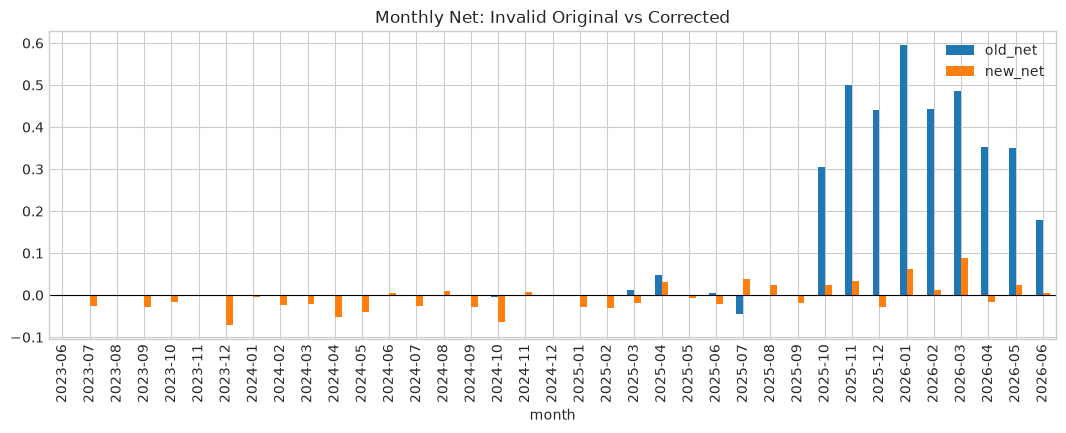

In [10]:
monthly_compare = old['monthly'][['month','net_return']].rename(columns={'net_return':'old_net'}).merge(
    new['monthly'][['month','net_return']].rename(columns={'net_return':'new_net'}), on='month', how='outer'
).fillna(0)
display(monthly_compare)
fig, ax = plt.subplots(figsize=(13, 4))
monthly_compare.set_index('month')[['old_net','new_net']].plot.bar(ax=ax)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('Monthly Net: Invalid Original vs Corrected')
plt.show()


## Root Attribution

,old_invalid,new_corrected
GC,0.706727,0.044845
SI,0.633147,-0.014747
HG,0.822639,0.016128
PL,0.874352,0.188023
PA,0.989807,-0.051657


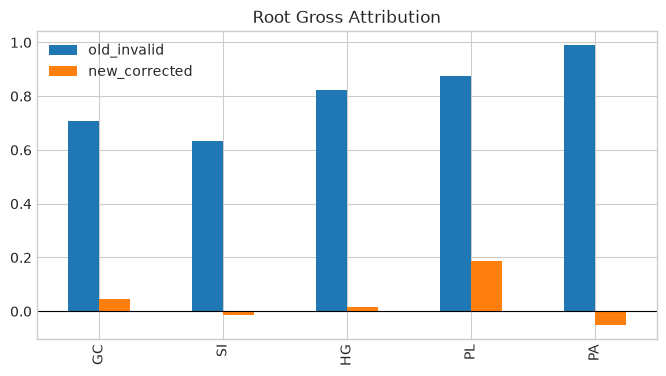

In [11]:
def root_attribution(exp):
    selected = exp['selected']
    return pd.Series({r: selected[f'{r}_gross_return'].sum() for r in ROOTS}, name='gross')
attr = pd.concat([
    root_attribution(old).rename('old_invalid'),
    root_attribution(new).rename('new_corrected'),
], axis=1)
display(attr)
fig, ax = plt.subplots(figsize=(8, 4))
attr.plot.bar(ax=ax)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('Root Gross Attribution')
plt.show()


## Price Validity And Contract Diagnostics

In [12]:
valid = new['price_validity']
cont = new['continuous_marks']
endp = new['endpoint_symbols']
rows = []
for r in ROOTS:
    rows.append({
        'root': r,
        'flow_endpoint_symbol_switch_rate': endp[f'{r}_flow_endpoint_symbol'].astype('string').ne(endp[f'{r}_flow_endpoint_symbol'].astype('string').shift()).fillna(False).mean(),
        'continuous_active_switch_count': int(cont[f'{r}_active'].astype('string').ne(cont[f'{r}_active'].astype('string').shift()).fillna(False).sum()),
        'fresh_fraction': float(valid[f'{r}_fresh'].mean()),
        'median_staleness_sec': float(cont[f'{r}_staleness_seconds'].median()),
        'p99_staleness_sec': float(cont[f'{r}_staleness_seconds'].quantile(.99)),
    })
contract_diag = pd.DataFrame(rows)
display(contract_diag)

display(valid[['fresh_all','roll_any','roll_invalid','valid_price_mask']].mean().rename('fraction'))


,root,flow_endpoint_symbol_switch_rate,continuous_active_switch_count,fresh_fraction,median_staleness_sec,p99_staleness_sec
0,GC,0.095001,15,1.000000,27.908850,59.347917
1,SI,0.096867,15,1.000000,28.044345,59.621872
2,HG,0.170164,15,1.000000,28.406127,87.112126
3,PL,0.106468,12,0.999938,29.011129,116.634966
4,PA,0.061619,12,0.998769,39.951166,976.788197


fresh_all           0.998749
roll_any            0.000240
roll_invalid        0.000710
valid_price_mask    0.998059
Name: fraction, dtype: float64

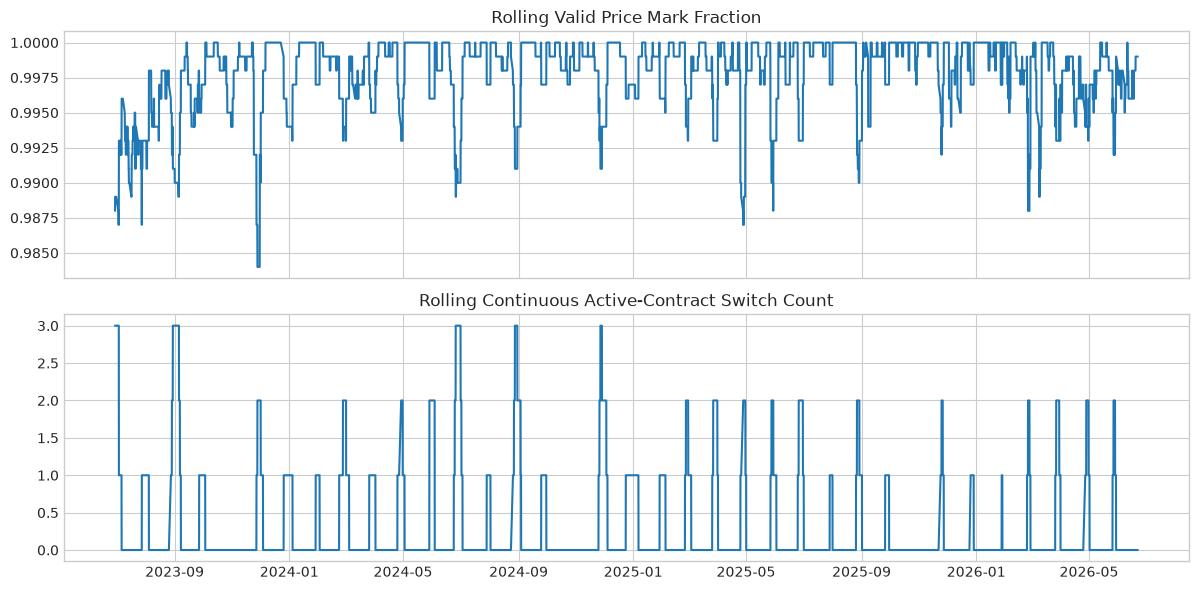

In [13]:
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
ts = pd.to_datetime(new['bars']['end_ts'], utc=True)
axes[0].plot(ts, valid['valid_price_mask'].rolling(1000).mean())
axes[0].set_title('Rolling Valid Price Mark Fraction')
axes[1].plot(ts, valid['roll_any'].astype(float).rolling(1000).sum())
axes[1].set_title('Rolling Continuous Active-Contract Switch Count')
fig.tight_layout()
plt.show()


## Leak-Controlled Thresholds

,month,bars,md_threshold_median,large_small_threshold_median,md_pass_rate,large_small_pass_rate,entry_rate,entries
0,2023-06,1287,NaN,NaN,0.000000,0.000000,0.000000,0
1,2023-07,3877,2.885231,0.247945,0.071189,0.227753,0.039206,152
2,2023-08,3901,2.902376,0.251717,0.099718,0.376570,0.050756,198
3,2023-09,3814,2.870722,0.264971,0.094127,0.286314,0.041426,158
4,2023-10,4659,2.856365,0.259613,0.098304,0.209916,0.046147,215
5,2023-11,4199,2.873939,0.252820,0.100976,0.310788,0.053584,225
6,2023-12,3929,2.869801,0.254081,0.105879,0.310003,0.054212,213
7,2024-01,4469,2.831551,0.252230,0.088163,0.310360,0.051242,229
8,2024-02,3973,2.860425,0.249858,0.107979,0.348855,0.064687,257
9,2024-03,5503,2.864763,0.254769,0.097220,0.276758,0.055969,308


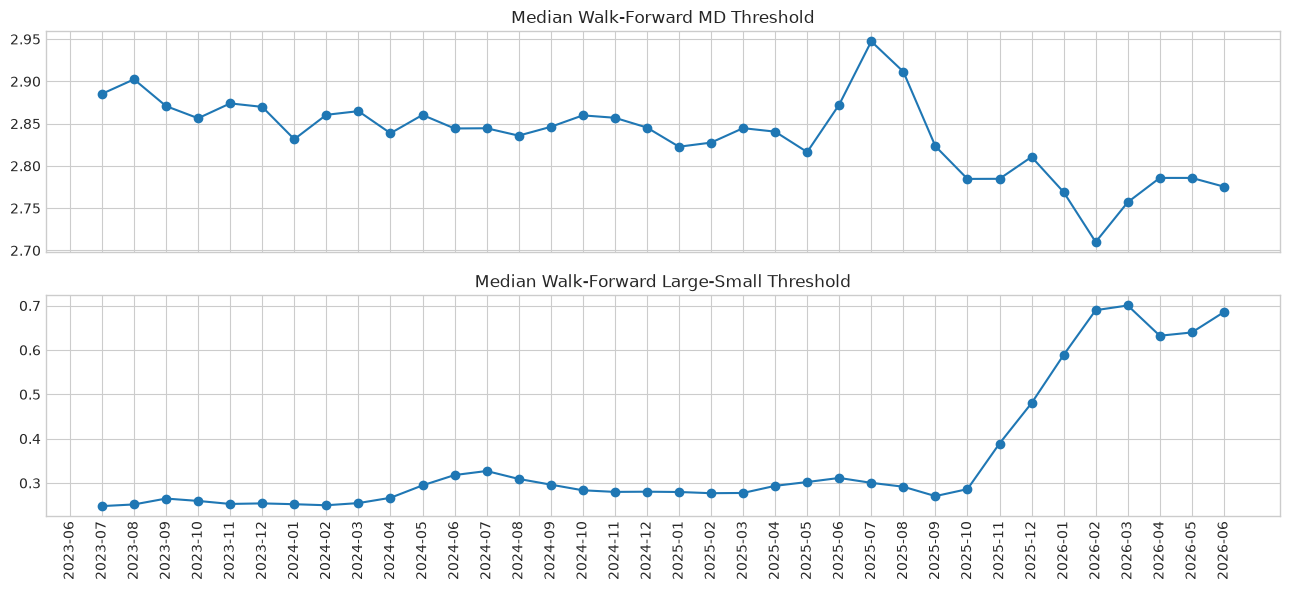

In [14]:
display(new['leakage_diagnostics'])
fig, axes = plt.subplots(2, 1, figsize=(13, 6), sharex=True)
ld = new['leakage_diagnostics']
axes[0].plot(ld['month'], ld['md_threshold_median'], marker='o')
axes[0].set_title('Median Walk-Forward MD Threshold')
axes[1].plot(ld['month'], ld['large_small_threshold_median'], marker='o')
axes[1].set_title('Median Walk-Forward Large-Small Threshold')
for ax in axes:
    ax.tick_params(axis='x', rotation=90)
fig.tight_layout()
plt.show()


## Information Coefficients

In [15]:
ic = new['ic_fdr'].assign(abs_ic=lambda x: x['spearman_ic'].abs()).sort_values('abs_ic', ascending=False)
display(ic.head(30))
flow_mask = ic['feature'].str.contains('md|large_small|very_large|entropy|hhi|distance_from_equal_weight', regex=True)
flow_summary = ic.loc[flow_mask].groupby('feature')['spearman_ic'].agg(['count','mean','median',lambda s: s.abs().max()]).rename(columns={'<lambda_0>':'max_abs'}).sort_values('max_abs', ascending=False)
display(flow_summary)


,feature,root,horizon,spearman_ic,pvalue,observations,bh_qvalue,abs_ic
53,rv_z_SI,PL,50,0.033908,5.458436e-59,227995,4.585087e-56,0.033908
29,rv_z_GC,PA,50,-0.030974,1.615324e-49,227995,6.784359e-47,0.030974
83,rv_z_HG,PL,50,0.030130,5.992923e-47,227995,1.678019e-44,0.030130
11,rv_z_GC,SI,50,-0.029629,1.848094e-45,227995,3.880997e-43,0.029629
640,SI_notional_share,SI,20,0.026421,7.799394e-38,236742,1.091915e-35,0.026421
564,GC_signed_notional_share,PA,1,0.026258,4.256263e-38,241433,7.150522e-36,0.026258
52,rv_z_SI,PL,20,0.023746,1.168634e-30,234901,1.402361e-28,0.023746
71,rv_z_HG,SI,50,0.023569,2.181968e-29,227995,2.291066e-27,0.023569
145,rv_z_PA,PA,2,-0.022787,7.472581e-29,239207,6.974409e-27,0.022787
767,PL_notional_share,HG,50,0.022780,9.425684e-28,229656,7.917575e-26,0.022780


,count,mean,median,max_abs
feature,,,,
distance_from_equal_weight,30,-0.000200,-0.000356,0.012616
hhi,30,-0.000200,-0.000356,0.012616
large_small_l1_distance,30,-0.000222,0.000261,0.010196
entropy_normalized,30,-0.000809,0.000004,0.010041
very_large_small_l1_distance,30,0.004108,0.003957,0.008961
md_ewma,30,0.002297,0.002420,0.006428
md_expanding,30,0.002297,0.002420,0.006428
md_rolling,30,0.002297,0.002420,0.006428


## Existing Plots

### strategy_equity_drawdown.png

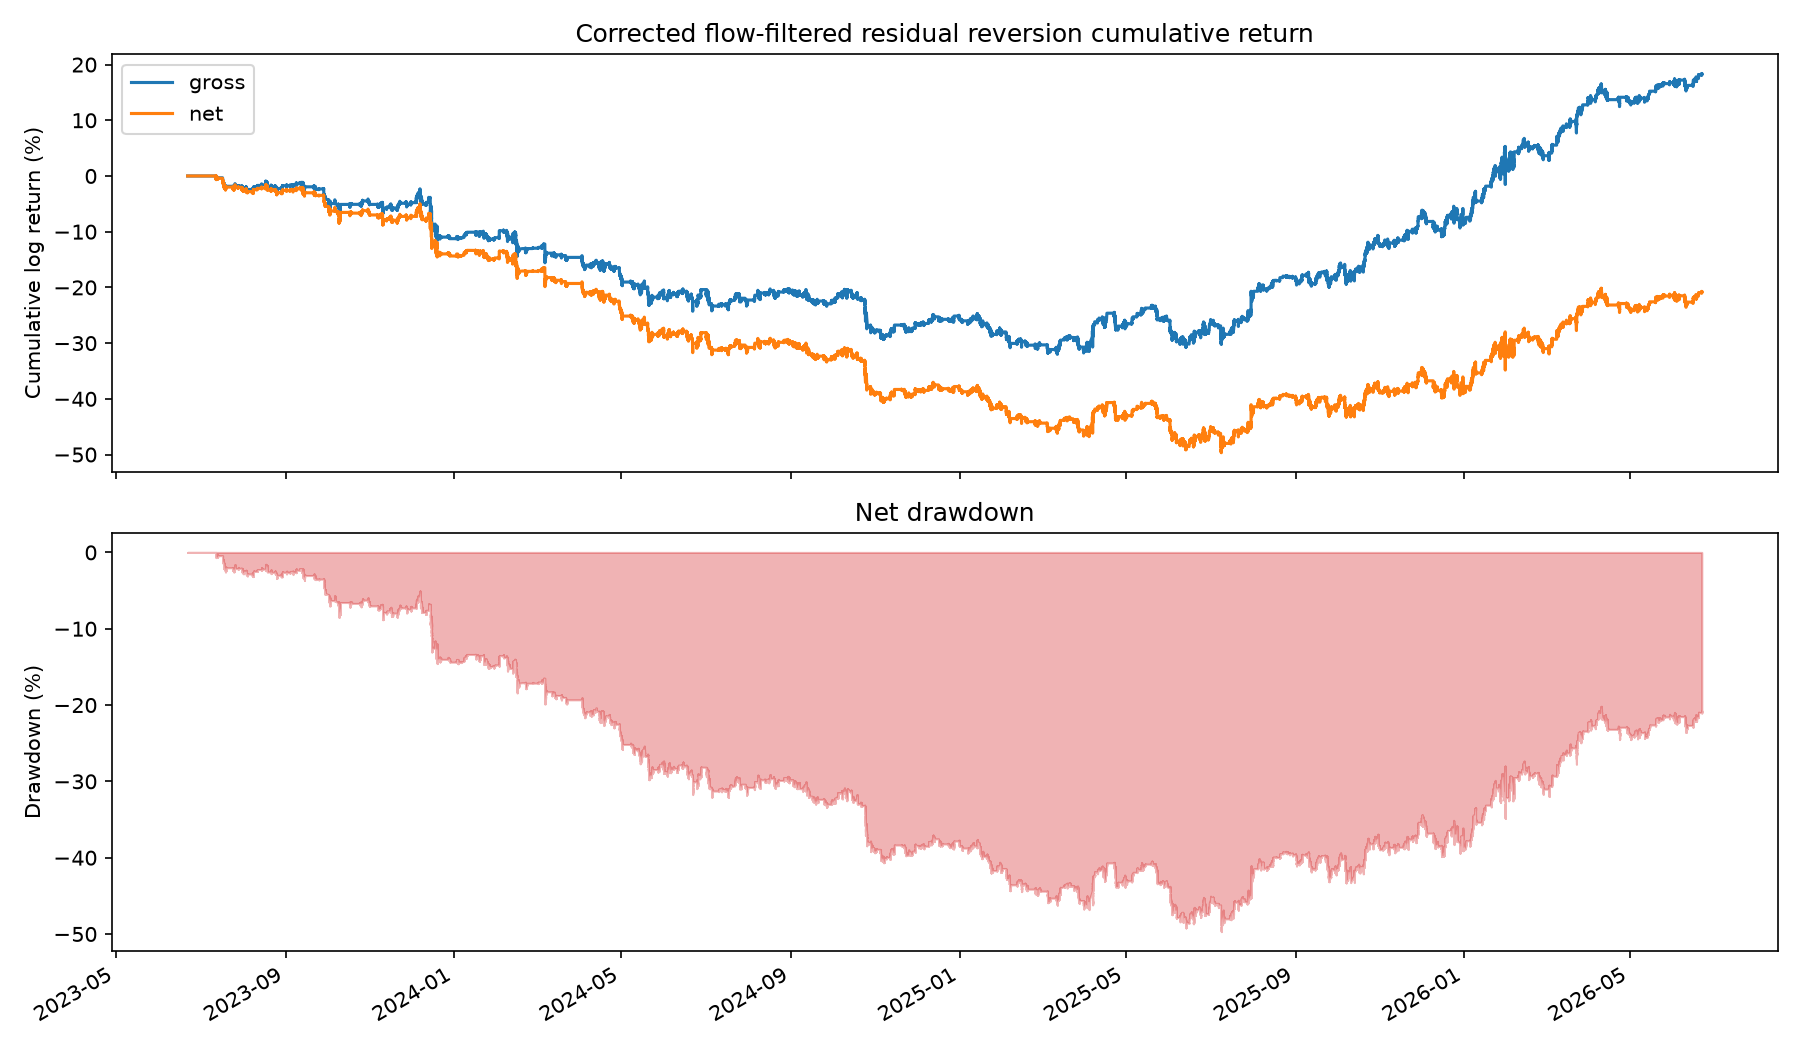

### monthly_returns.png

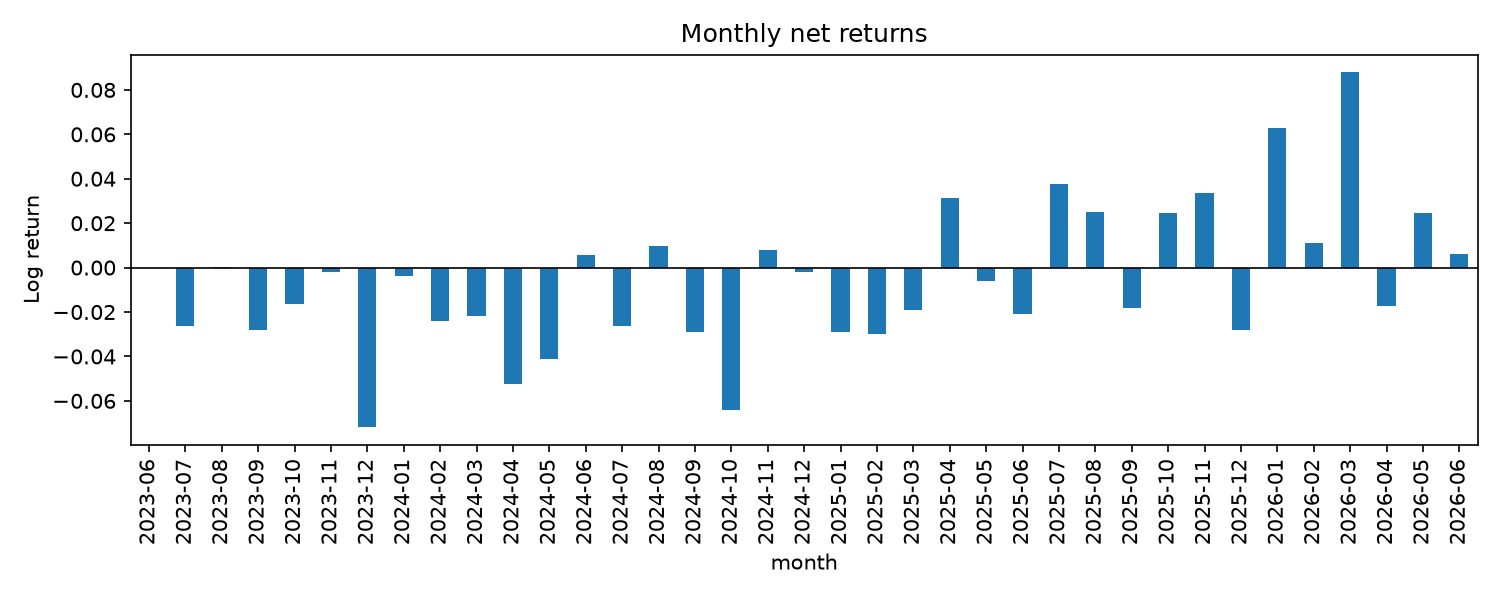

### cost_sensitivity.png

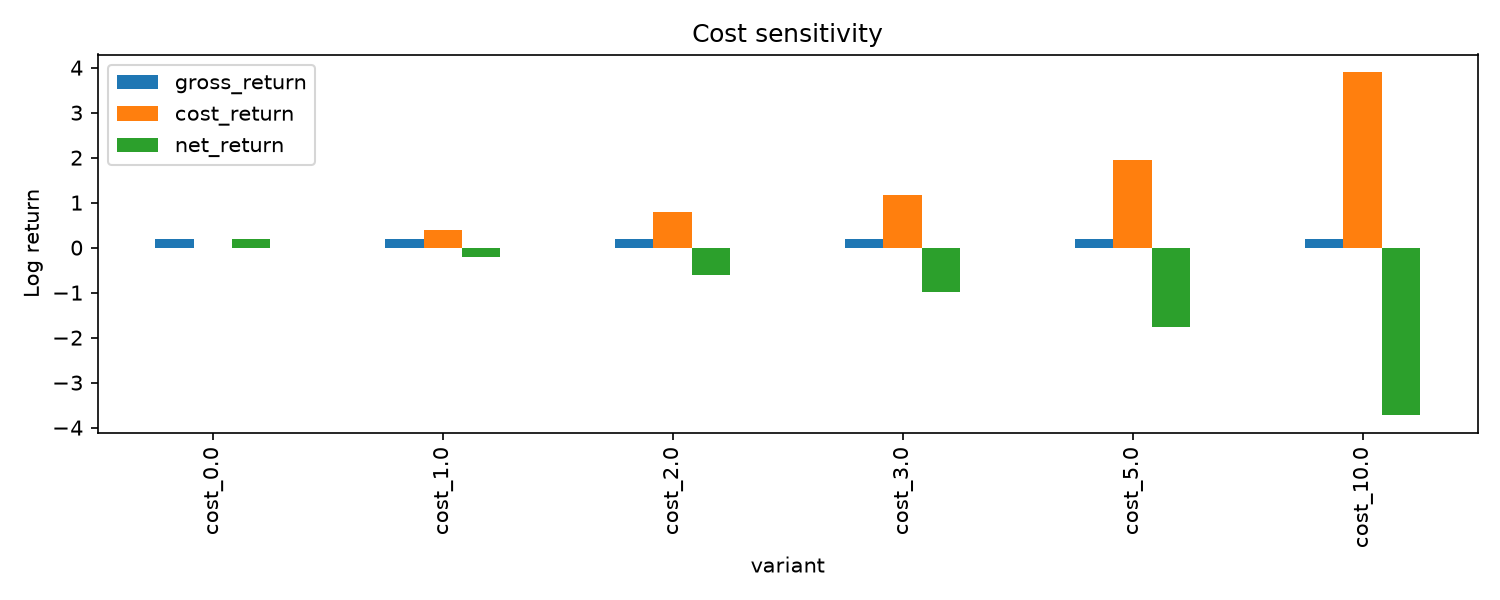

### flow_filters.png

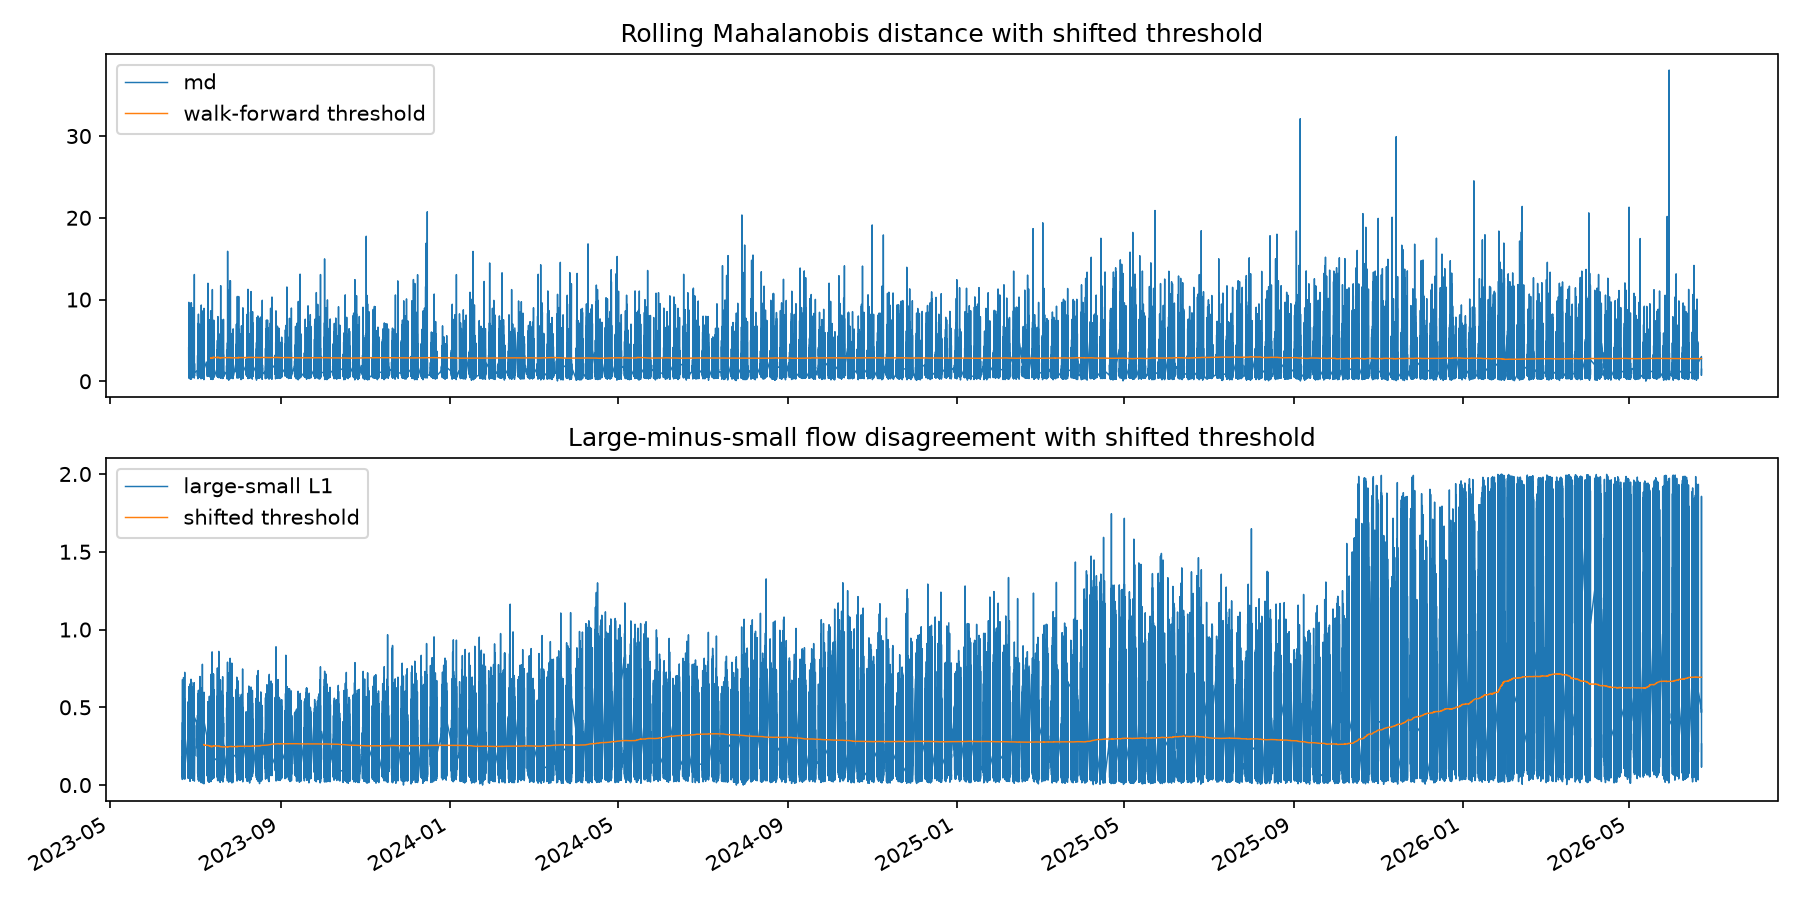

### price_validity.png

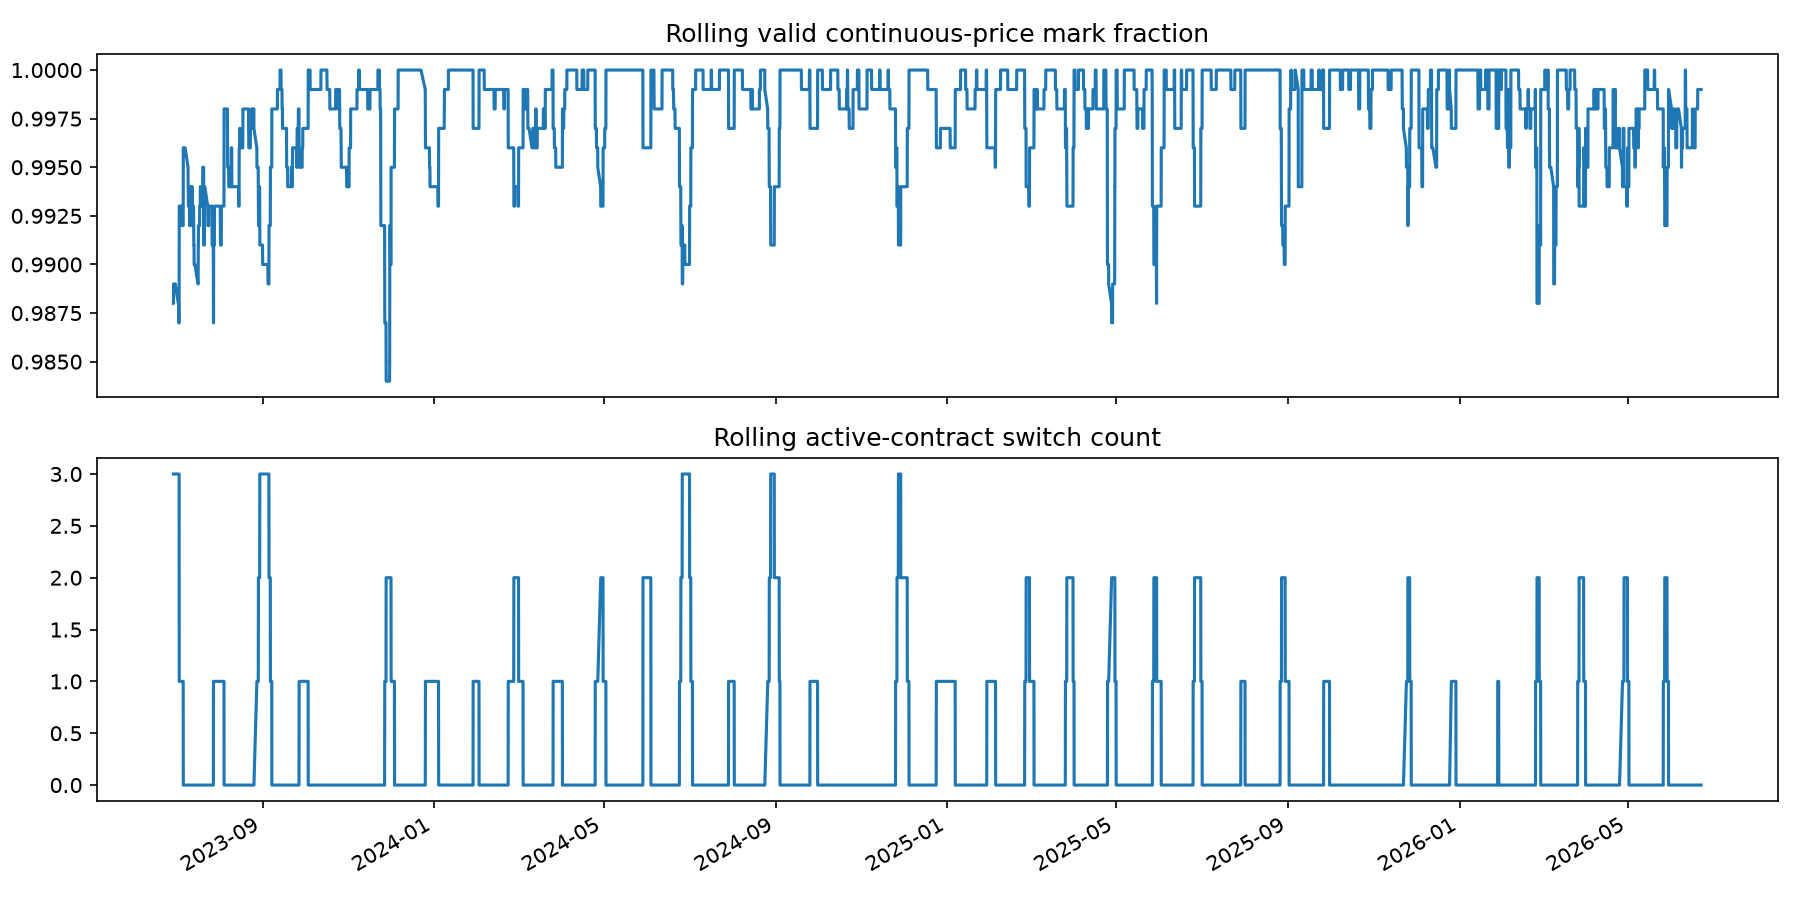

### gross_exposure.png

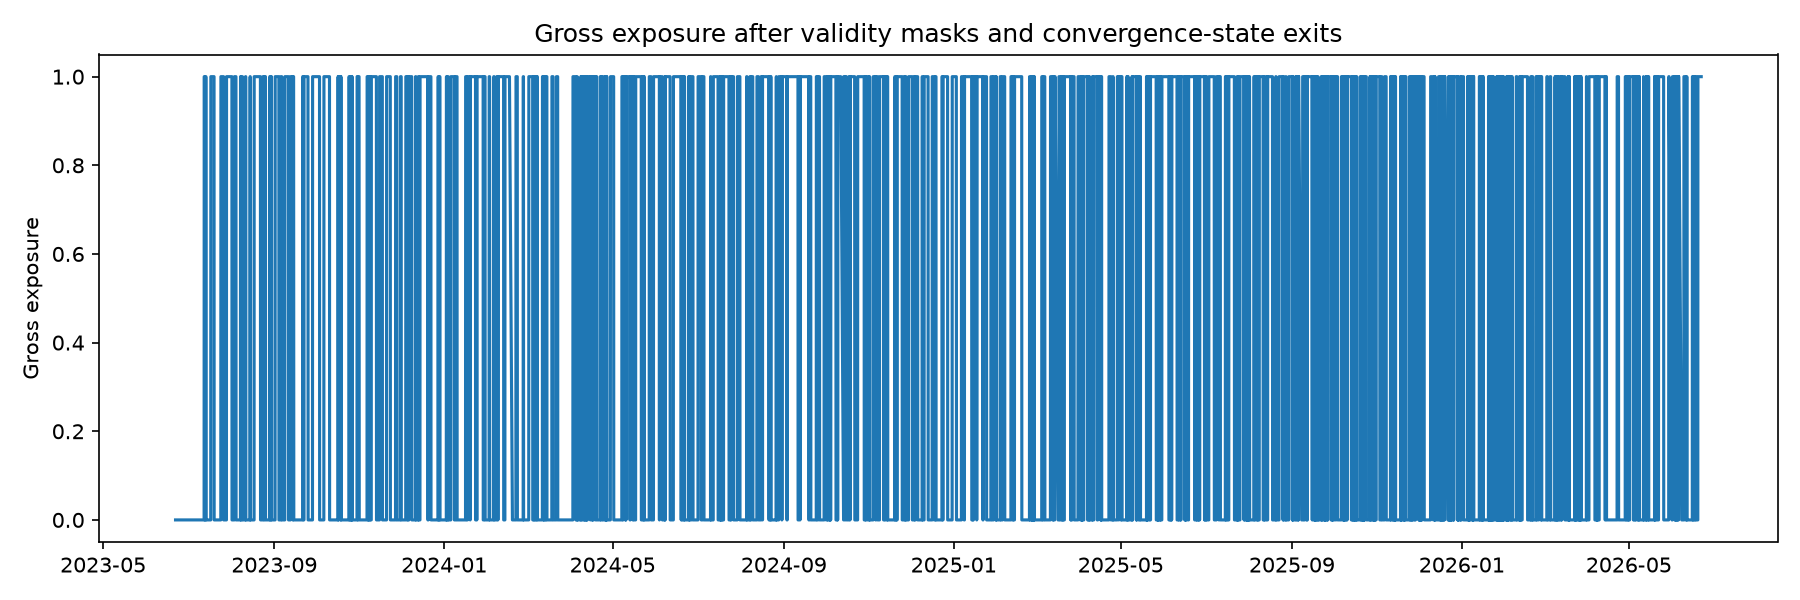

### residual_zscores.png

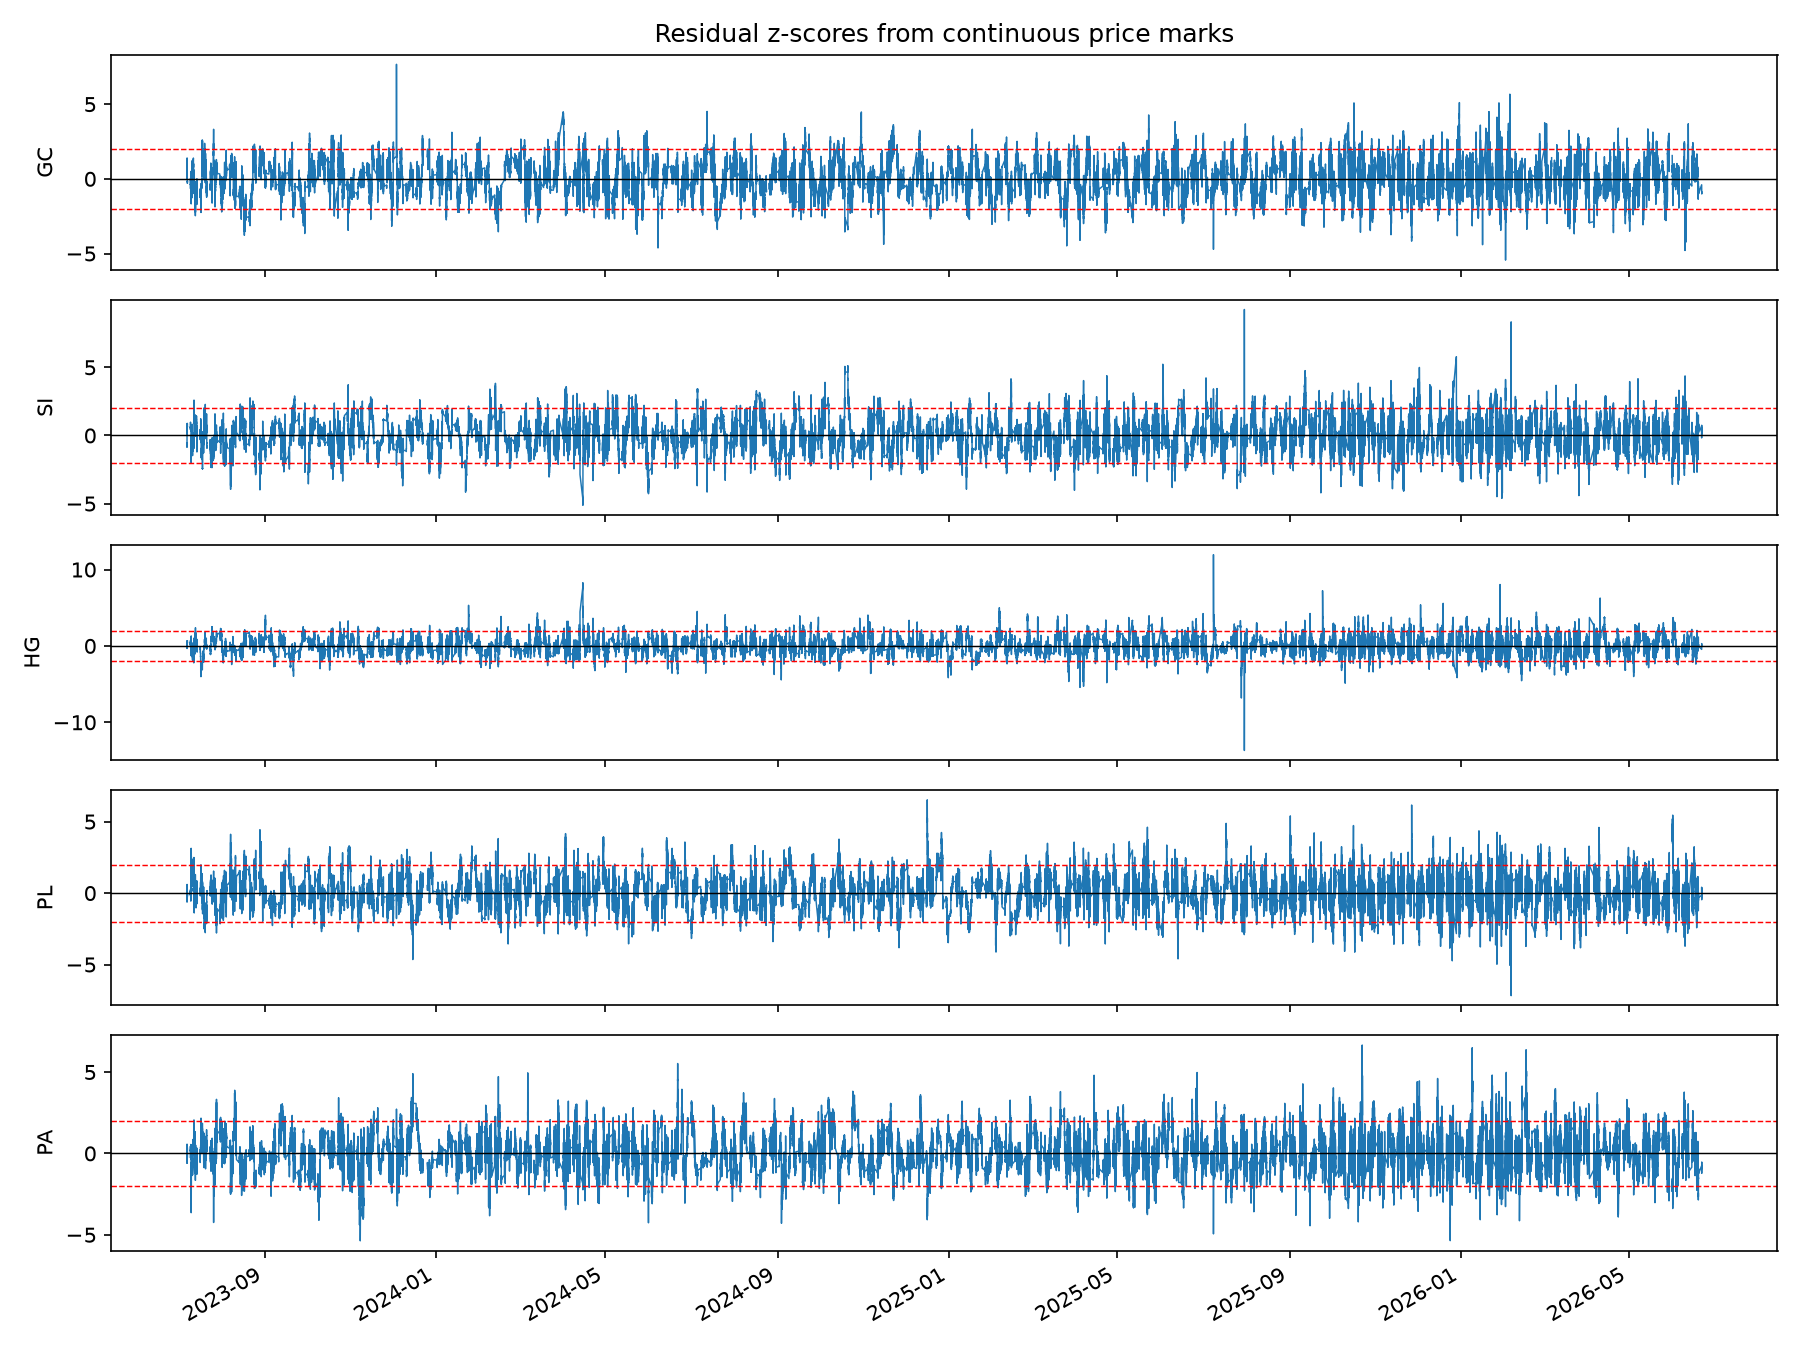

### top_ic.png

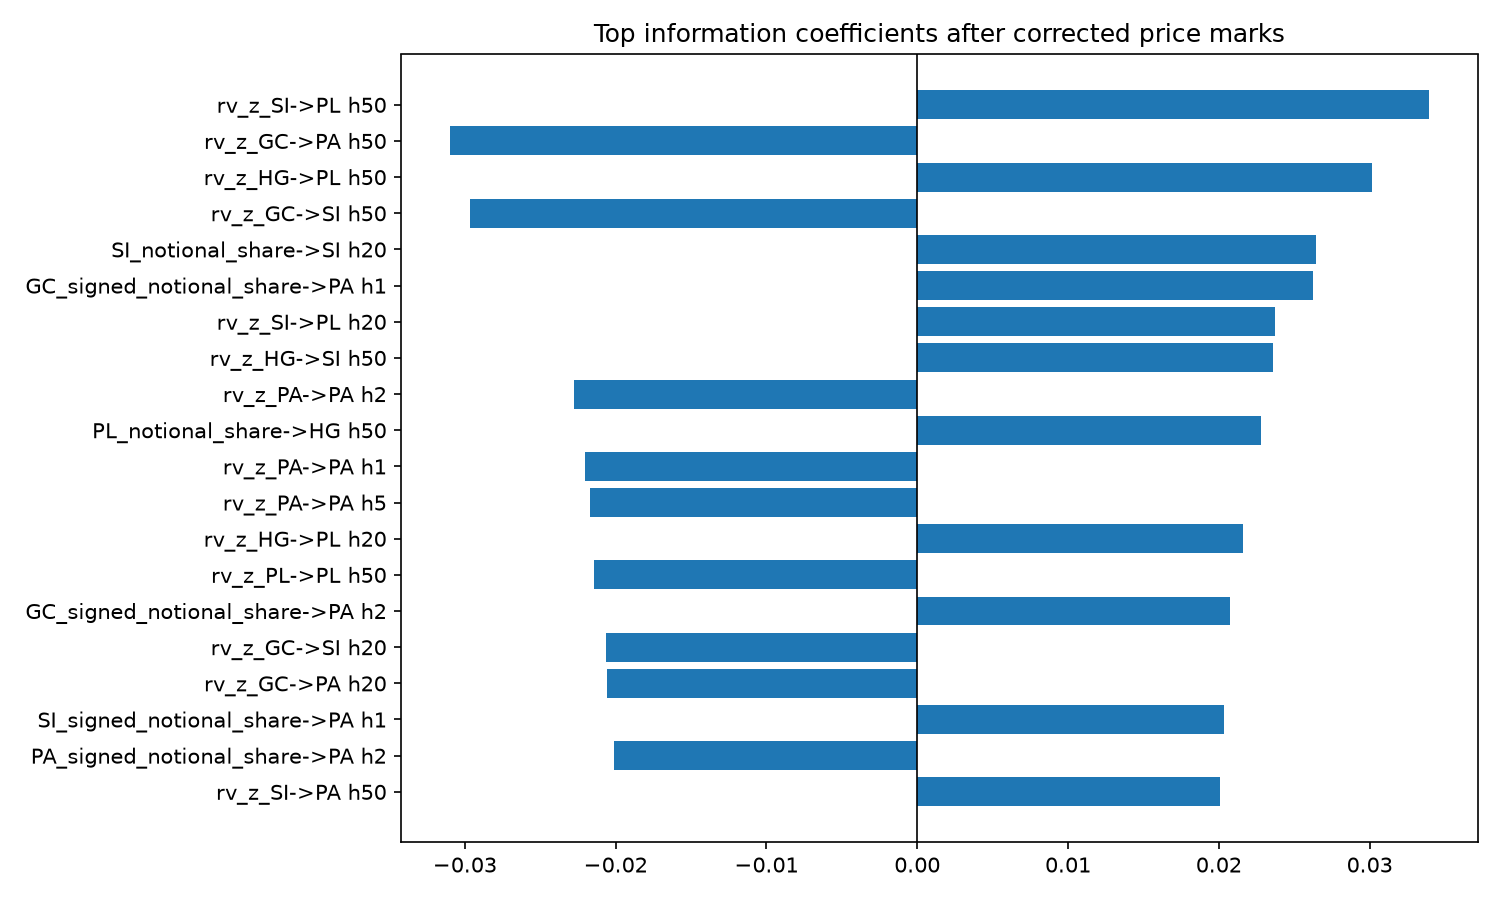

In [16]:
for plot in ['strategy_equity_drawdown.png','monthly_returns.png','cost_sensitivity.png','flow_filters.png','price_validity.png','gross_exposure.png','residual_zscores.png','top_ic.png']:
    display(Markdown(f'### {plot}'))
    display(Image(filename=str(NEW / 'plots' / plot)))


## Conclusion

The corrected validation rejects the HYP-0014 strategy claim. Once mixed-contract endpoint returns are removed and flow thresholds are made walk-forward, the strategy has weak positive gross return before costs and negative net return after base costs. The flow anomaly filter does not establish enough incremental information to overcome transaction costs.